# 04 — Saliency Maps (Captum)
Compute token-level attribution using LayerIntegratedGradients.
Includes side-by-side comparison of baseline vs LoRA attention patterns.

In [ ]:
# ── Colab setup ────────────────────────────────────────────────────────────
import os
from google.colab import drive, userdata   # ← add userdata here
IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    # Update this path if your outputs folder is elsewhere
    OUTPUT_BASE = '/content/drive/MyDrive/slm_logic_hardening/outputs'
    !pip install -q transformers datasets pyyaml sentencepiece
    # Navigate directly to your existing project folder in Drive
    %cd '/content/drive/MyDrive/slm_logic_hardening'
    from huggingface_hub import login
    login(token=userdata.get('HF_TOKEN'))
else:
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path().resolve()))
    OUTPUT_BASE = 'outputs'

os.environ['PYTORCH_MPS_HIGH_WATERMARK_RATIO'] = '0.0'

Mounted at /content/drive
/content/drive/MyDrive/slm_logic_hardening


In [ ]:
import torch
device = 'mps' if torch.backends.mps.is_available() else \
         'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


## Configuration

In [ ]:
import yaml
from pathlib import Path

MODEL_KEY = 'phi35'

# Load indices and n_steps from config — single source of truth
with open('configs/eval/saliency.yml') as f:
    saliency_cfg = yaml.safe_load(f)

SAMPLE_INDICES = [0, 2, 4, 8, 10, 12, 18, 24, 42, 50]
N_STEPS = 10

print(f'Sample indices ({len(SAMPLE_INDICES)}): {SAMPLE_INDICES}')
print(f'n_steps: {N_STEPS}')

# Experiment directories
BASELINE_DIR     = Path(OUTPUT_BASE) / 'phi35' / 'phi35_baseline'
LORA_DIR         = Path(OUTPUT_BASE) / 'phi35' / 'phi35_lora_folio_pw'
#LLAMA_DIR        = Path(OUTPUT_BASE) / 'llama8b' / 'llama8b_baseline'

LORA_ADAPTER     = str(LORA_DIR / 'final_adapter')

print(f'\nBaseline dir: {BASELINE_DIR}')
print(f'LoRA dir:     {LORA_DIR}')
print(f'LoRA adapter: {LORA_ADAPTER}')
#print(f'LLaMA dir:    {LLAMA_DIR}')

Sample indices (10): [0, 2, 4, 8, 10, 12, 18, 24, 42, 50]
n_steps: 10

Baseline dir: /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/phi35_baseline
LoRA dir:     /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/phi35_lora_folio_pw
LoRA adapter: /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/phi35_lora_folio_pw/final_adapter


Install Captum

In [ ]:
!pip install -q transformers peft datasets captum sentencepiece pyyaml

## 1. Compute baseline saliency

In [ ]:
from scripts.saliency import run_saliency

run_saliency(
    model_key=MODEL_KEY,
    mode='baseline',
    adapter_path=None,
    sample_indices=SAMPLE_INDICES,
    n_steps=N_STEPS,
    output_dir=BASELINE_DIR,
    experiment_id='phi35_baseline',
)

This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Map: 100%|##########| 1001/1001 [00:00<?, ? examples/s]

Map: 100%|##########| 203/203 [00:00<?, ? examples/s]


Example 0: ground_truth = Uncertain
Computing attributions...
Top 10 tokens:
  ▁Log                  132.114822
  ▁Re                   100.435028
  :                     68.404289
  ical                  64.404991
  ▁are                  52.083549
  oth                   51.973244
  one                   51.248520
  one                   40.722733
  :                     40.299137
  yp                    37.591328

Example 2: ground_truth = False
Computing attributions...
Top 10 tokens:
  ▁academic             191.201752
  :                     102.498161
  ▁Re                   73.814865
  ?                     71.196159
  ▁the                  68.489067
  :                     67.018921
  <0x0A>                56.162571
  ical                  54.263298
  ▁a                    41.021954
  ▁Log                  39.747364

Example 4: ground_truth = Uncertain
Computing attributions...
Top 10 tokens:
  ▁Re                   161.810730
  ical                  137.988556
  ▁Log          

## 2. Compute LoRA saliency

In [ ]:
from scripts.saliency import run_saliency
run_saliency(
    model_key=MODEL_KEY,
    mode='lora',
    adapter_path=LORA_ADAPTER,
    sample_indices=SAMPLE_INDICES,
    n_steps=N_STEPS,
    output_dir=LORA_DIR,
    experiment_id='phi35_lora_folio_pw',
)

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Map: 100%|##########| 1001/1001 [00:00<?, ? examples/s]

Map: 100%|##########| 203/203 [00:00<?, ? examples/s]


Example 0: ground_truth = Uncertain
Computing attributions...
Top 10 tokens:
  ▁Re                   406.843201
  ical                  300.468933
  ▁Log                  219.969452
  ▁You                  96.096725
  ▁a                    76.139938
  :                     43.585197
  :                     42.711918
  ▁are                  41.933235
  oth                   38.371655
  ▁or                   35.331078

Example 2: ground_truth = False
Computing attributions...
Top 10 tokens:
  ▁Re                   246.631210
  ▁academic             203.685852
  ical                  198.797272
  :                     170.007294
  ?                     79.017136
  :                     72.078857
  ises                  66.930862
  ▁Log                  66.875648
  <0x0A>                53.813667
  ▁further              36.711060

Example 4: ground_truth = Uncertain
Computing attributions...
Top 10 tokens:
  ▁Re                   216.505737
  ical                  165.792816
  ▁Log       

## 3. Side-by-side comparison (before vs after fine-tuning)

Baseline loaded: 10 | LoRA loaded: 10


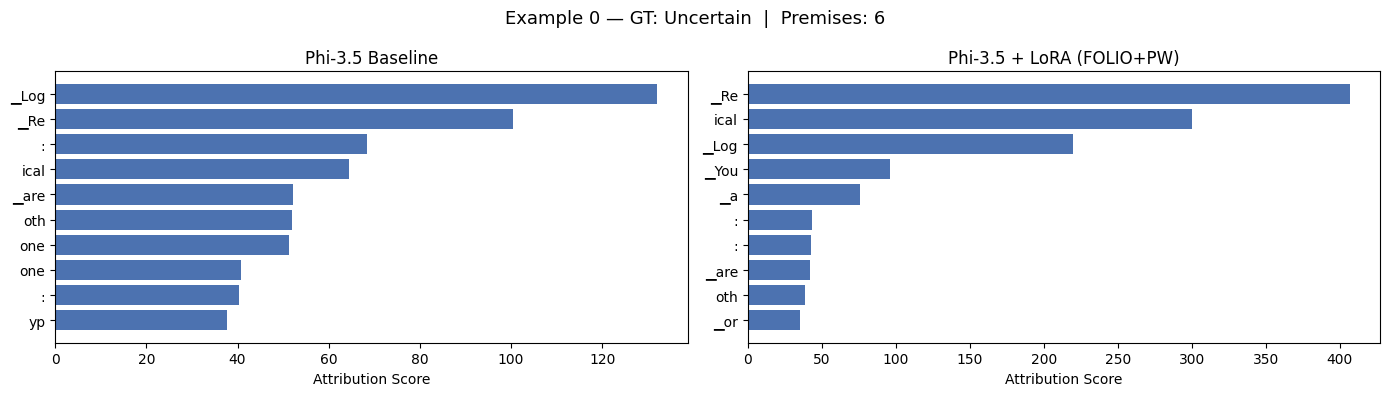

Saved: /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/saliency_comparison_0.png


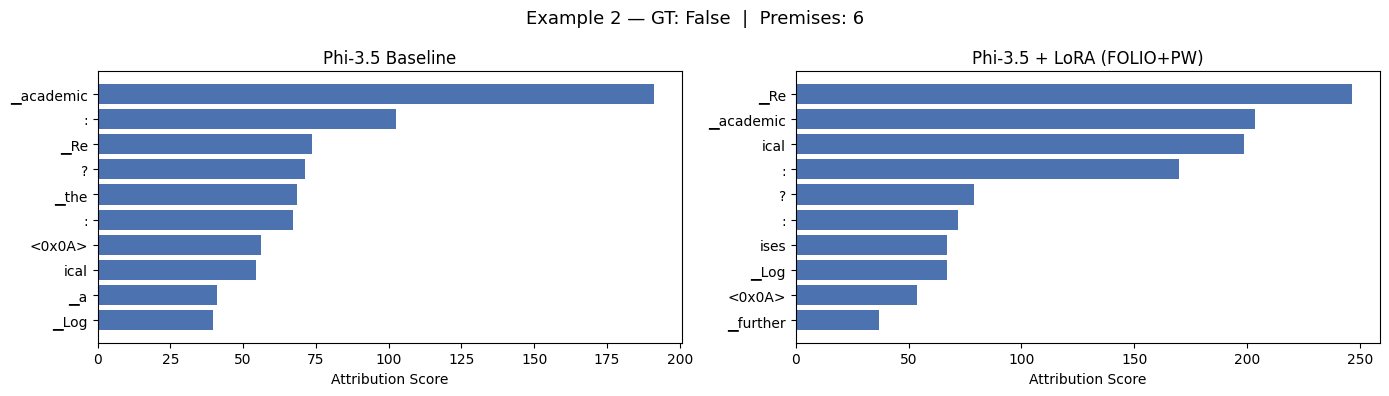

Saved: /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/saliency_comparison_2.png


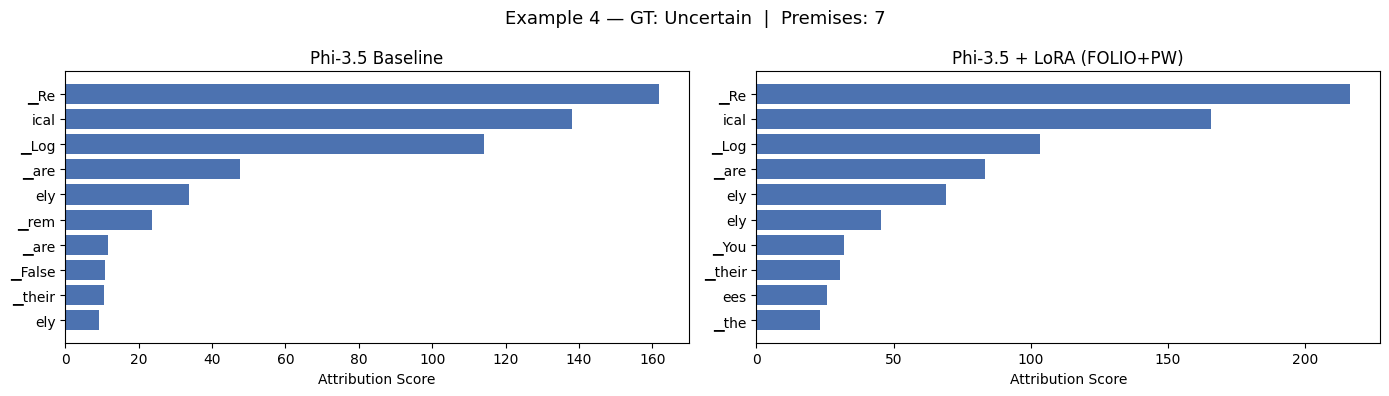

Saved: /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/saliency_comparison_4.png


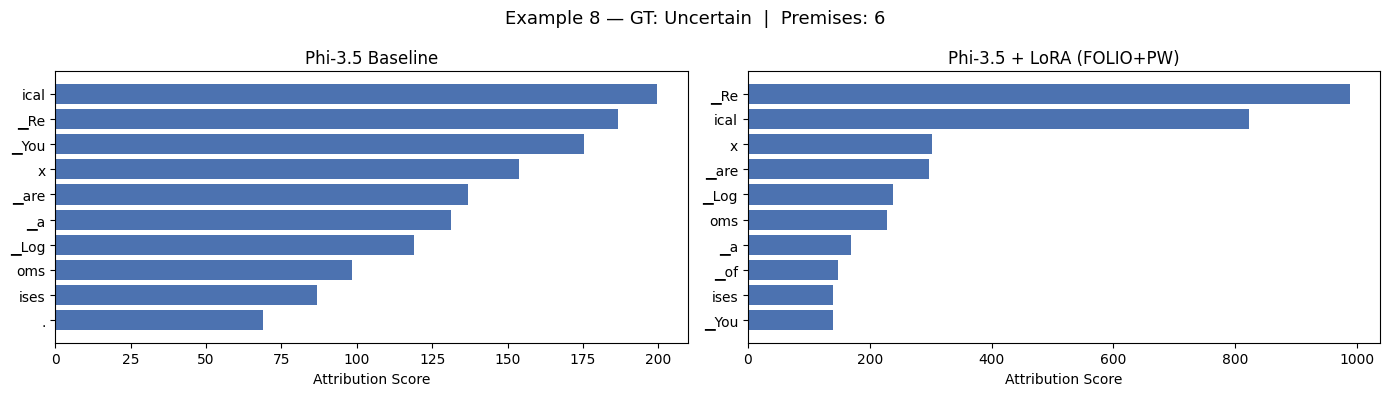

Saved: /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/saliency_comparison_8.png


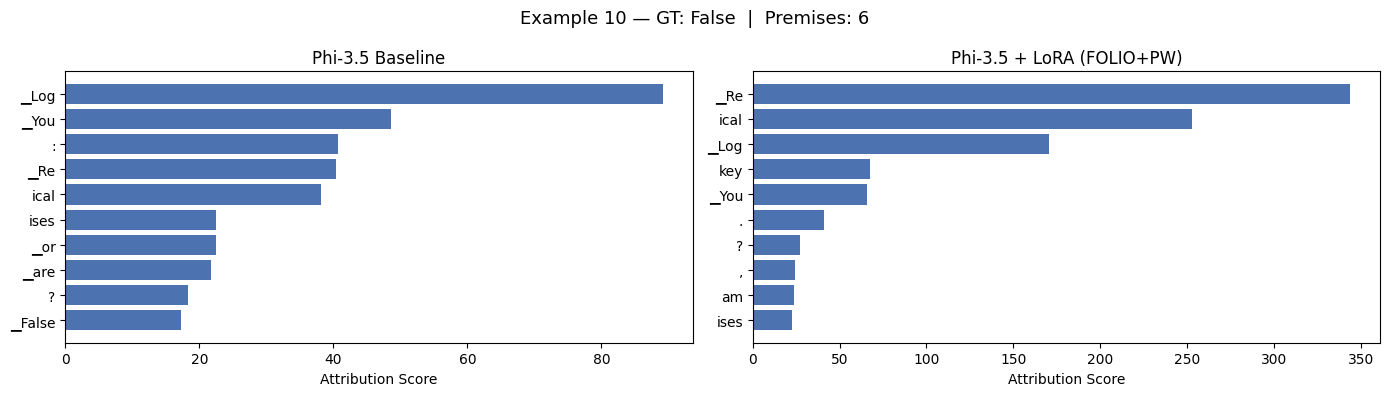

Saved: /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/saliency_comparison_10.png


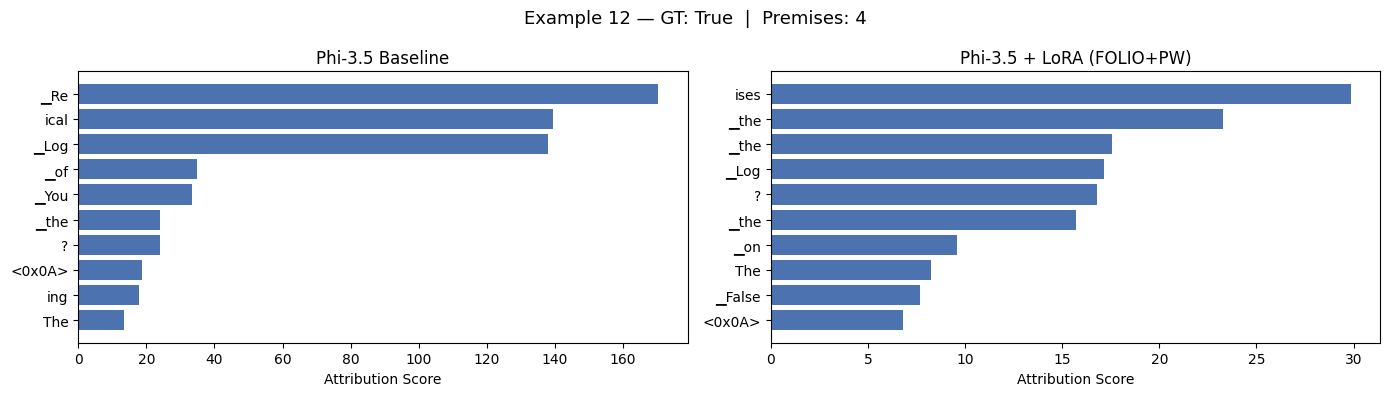

Saved: /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/saliency_comparison_12.png


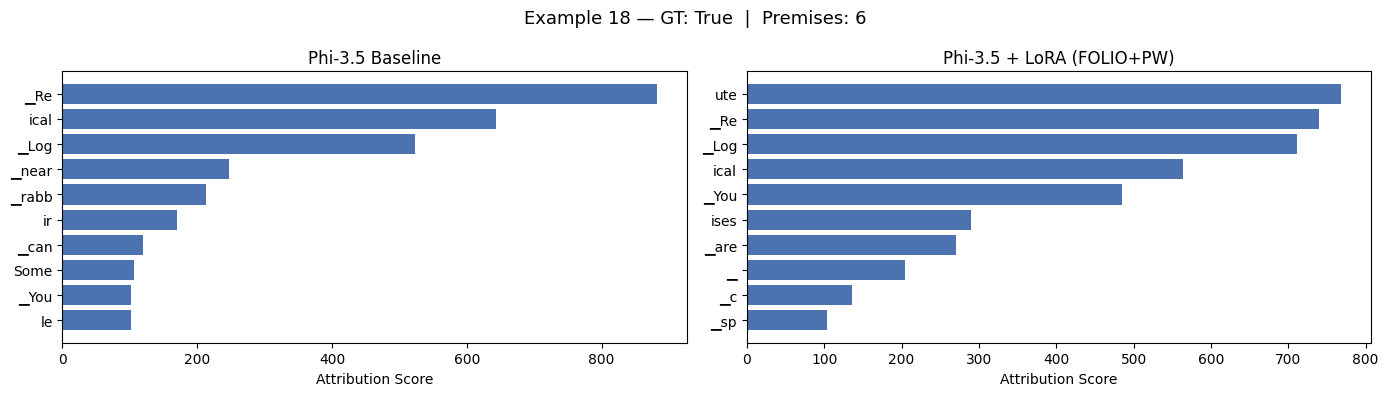

Saved: /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/saliency_comparison_18.png


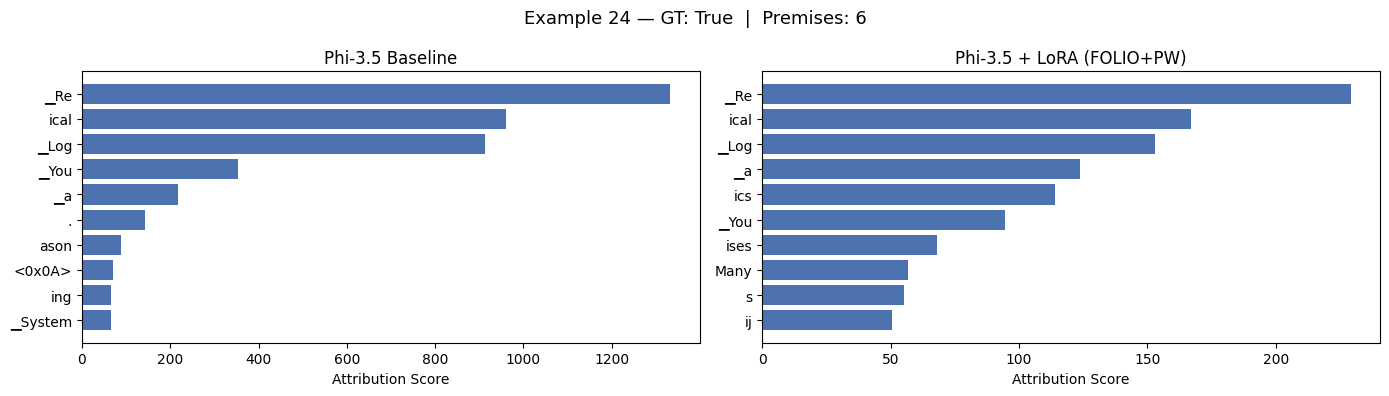

Saved: /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/saliency_comparison_24.png


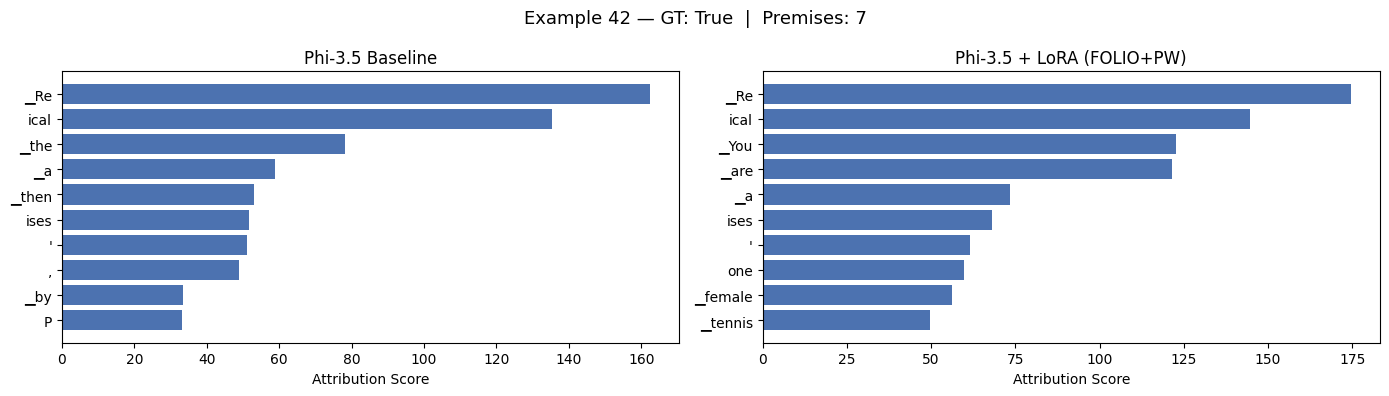

Saved: /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/saliency_comparison_42.png


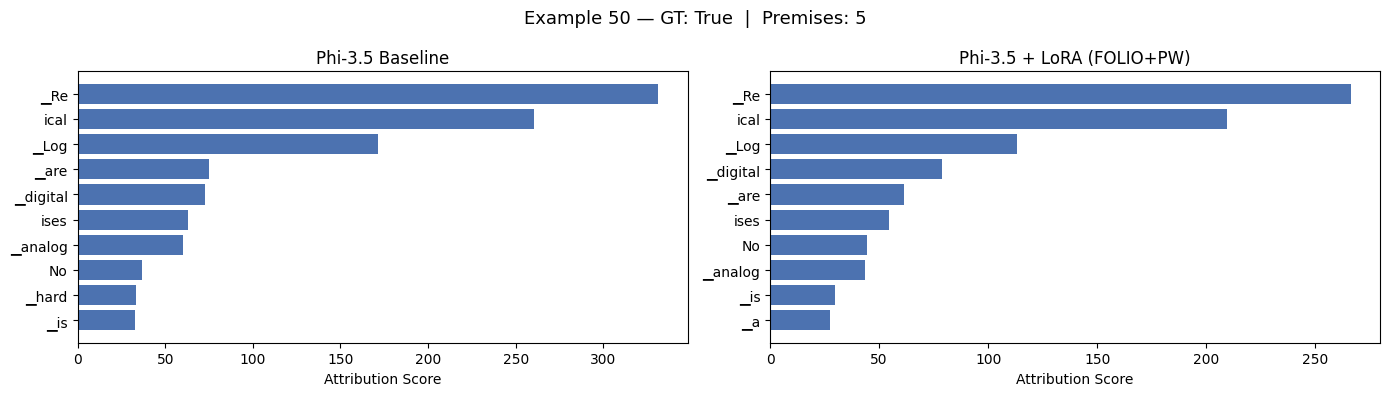

Saved: /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/saliency_comparison_50.png


In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def load_saliency_dir(saliency_dir: Path, indices: list) -> dict:
    results = {}
    for idx in indices:
        f = saliency_dir / 'saliency' / f'{idx}.json'
        if f.exists():
            with open(f) as fp:
                results[idx] = json.load(fp)
    return results

def top_n(attributions, n=10):
    return sorted(attributions, key=lambda x: x['score'], reverse=True)[:n]

baseline_sal = load_saliency_dir(BASELINE_DIR, SAMPLE_INDICES)
lora_sal     = load_saliency_dir(LORA_DIR, SAMPLE_INDICES)

print(f'Baseline loaded: {len(baseline_sal)} | LoRA loaded: {len(lora_sal)}')

for idx in SAMPLE_INDICES:
    if idx not in baseline_sal or idx not in lora_sal:
        print(f'Skipping {idx} — not computed yet')
        continue

    b_res = baseline_sal[idx]
    l_res = lora_sal[idx]
    label = b_res['ground_truth']
    premises = b_res.get('no_of_premises', '?')

    b_top = top_n(b_res['attributions'])
    l_top = top_n(l_res['attributions'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Example {idx} — GT: {label}  |  Premises: {premises}', fontsize=13)

    for ax, top, title in [
        (axes[0], b_top, 'Phi-3.5 Baseline'),
        (axes[1], l_top, 'Phi-3.5 + LoRA (FOLIO+PW)'),
    ]:
        tokens = [t['token'] for t in top]
        scores = [t['score'] for t in top]
        y_pos = np.arange(len(tokens))
        ax.barh(y_pos, scores, color='#4C72B0')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(tokens)
        ax.invert_yaxis()
        ax.set_title(title)
        ax.set_xlabel('Attribution Score')

    plt.tight_layout()
    out = BASELINE_DIR.parent / f'saliency_comparison_{idx}.png'
    plt.savefig(out, dpi=150)
    plt.show()
    print(f'Saved: {out}')
